# Parametric working memory

## 1. Setup

In [3]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from low_rank_rnn.plotting import set_plot_style

set_plot_style()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Task configuration

The values below come directly from the project brief. Keeping them together makes the future experiment easy to review and modify.

In [4]:
BASE_SEED = 2026
TRIAL_LENGTH = 75
FIRST_STIMULUS_WINDOW = (5, 10)
SECOND_STIMULUS_WINDOW = (60, 70)
DECISION_STEPS = 5

FREQUENCIES = np.array([10, 14, 18, 22, 26, 30, 34], dtype=float)
MIN_FREQUENCY = float(FREQUENCIES.min())
MAX_FREQUENCY = float(FREQUENCIES.max())

NUM_TRAIN_TRIALS = 200
NUM_TEST_TRIALS = 160
NUM_UNITS = 128
RANK = 2
TARGET_LOSS = 5e-3

rng = np.random.default_rng(BASE_SEED)
_ = torch.manual_seed(BASE_SEED)

## 2. Generate task trials

Each trial has a first stimulus during $5 \leq t \leq 10$, a delay, and a second stimulus during $60 \leq t \leq 70$; the input is zero at all other time steps. Frequencies $f_1$ and $f_2$ are sampled independently and uniformly from `FREQUENCIES`.

The scalar stimulus values are

$$
u_i = \frac{1}{f_{\max} - f_{\min}}
\left(f_i - \frac{f_{\max} + f_{\min}}{2}\right),
\qquad i \in \{1, 2\},
$$

and the target is the normalized difference

$$
y = \frac{f_1 - f_2}{f_{\max} - f_{\min}}.
$$

Future data-generation code should return batched inputs, targets, and enough trial metadata to inspect the sampled frequency pairs.

In [5]:
def generate_parametric_working_memory_trials(num_trials, trial_length, rng):
    f_i = rng.choice(FREQUENCIES, size=(num_trials, 2))
    u_i = (f_i - (MAX_FREQUENCY + MIN_FREQUENCY) / 2) / (MAX_FREQUENCY - MIN_FREQUENCY)
    y = (f_i[:, 0] - f_i[:, 1]) / (MAX_FREQUENCY - MIN_FREQUENCY)
    first_start, first_end = FIRST_STIMULUS_WINDOW
    second_start, second_end = SECOND_STIMULUS_WINDOW
    u = np.zeros((num_trials, trial_length))
    u[:, first_start : first_end + 1] = u_i[:, 0, None]
    u[:, second_start : second_end + 1] = u_i[:, 1, None]
    return u, y, f_i


### Check representative trials

Plot several inputs and verify both stimulus windows, sampled frequency pairs, normalized stimulus values, and targets before training.

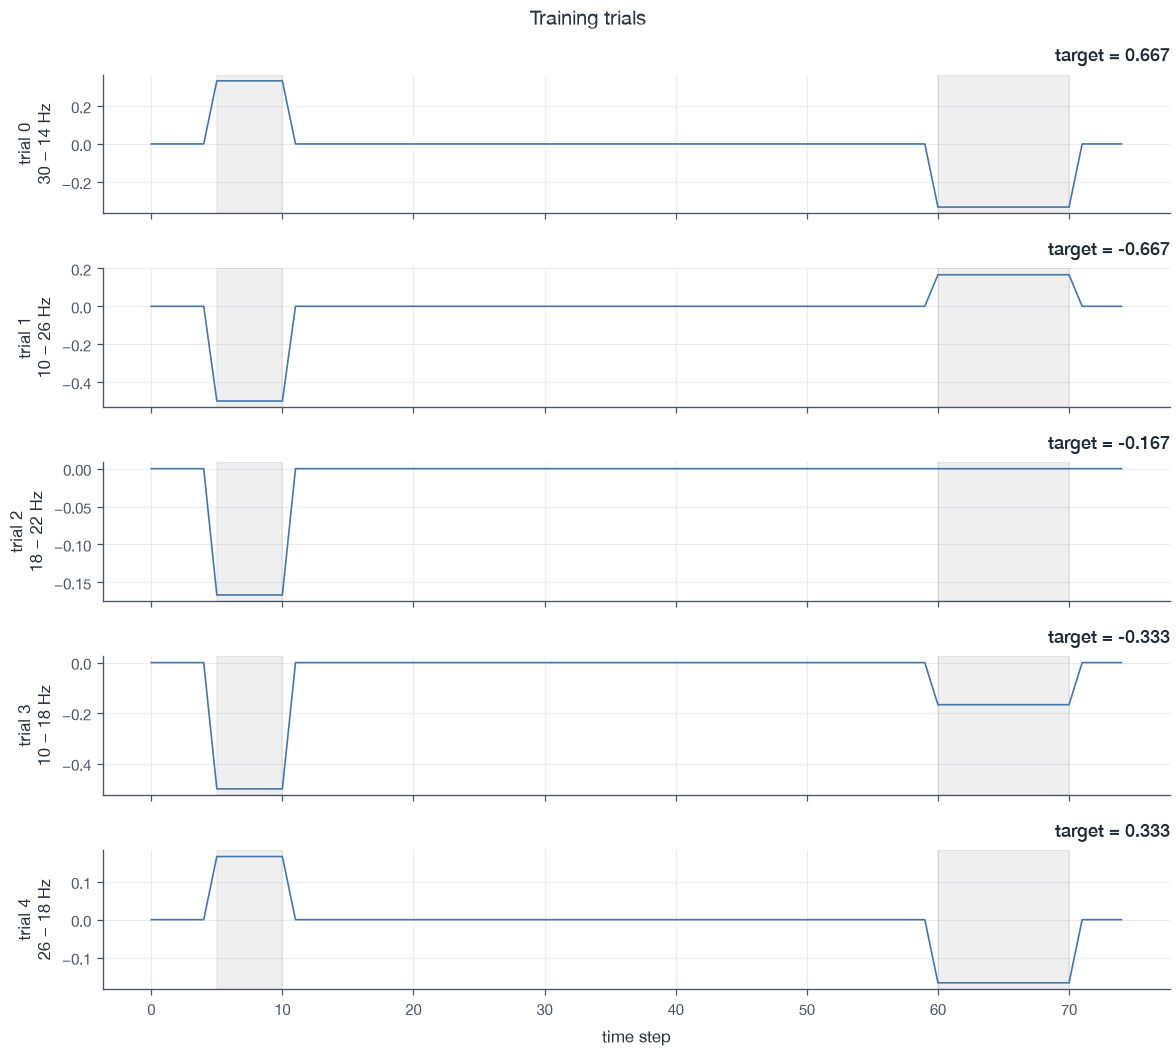

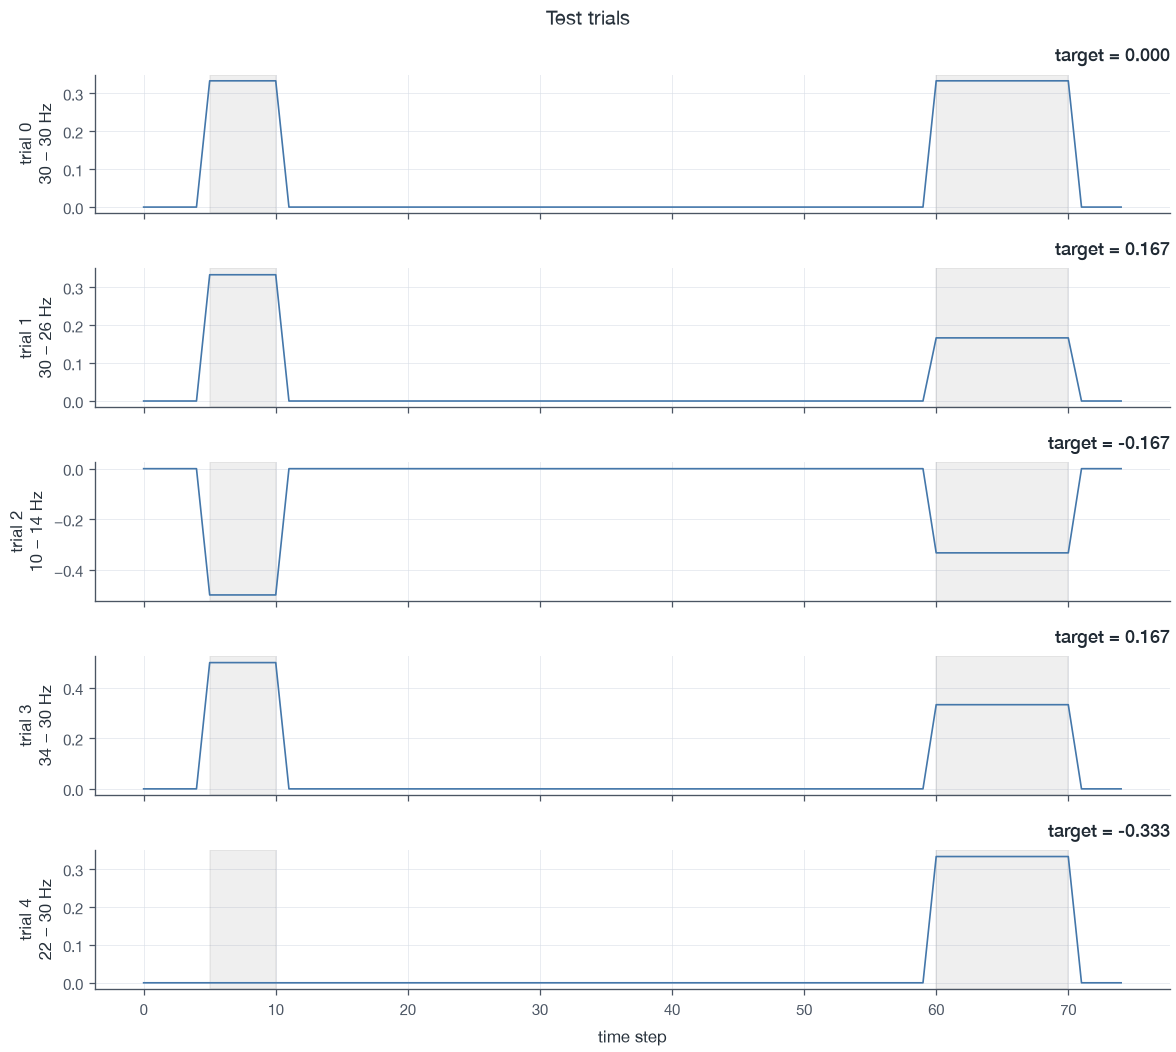

In [6]:
def plot_parametric_working_memory_trials(
    inputs,
    targets,
    frequencies,
    *,
    num_trials=5,
    title="Parametric working-memory trials",
):
    num_plotted = min(num_trials, len(inputs))
    time_steps = np.arange(inputs.shape[1])
    fig, axes = plt.subplots(
        num_plotted,
        1,
        figsize=(10, 1.8 * num_plotted),
        sharex=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for trial, ax in enumerate(axes):
        ax.plot(time_steps, inputs[trial], lw=1)
        ax.axvspan(*FIRST_STIMULUS_WINDOW, color="gray", alpha=0.12)
        ax.axvspan(*SECOND_STIMULUS_WINDOW, color="gray", alpha=0.12)
        f_1, f_2 = frequencies[trial]
        ax.set_ylabel(f"trial {trial}\n{f_1:g} − {f_2:g} Hz")
        ax.set_title(f"target = {targets[trial]:.3f}", loc="right")

    axes[-1].set_xlabel("time step")
    fig.suptitle(title)
    fig.tight_layout()
    return fig, axes


train_inputs, train_targets, train_frequencies = generate_parametric_working_memory_trials(
    NUM_TRAIN_TRIALS,
    TRIAL_LENGTH,
    rng,
)
test_inputs, test_targets, test_frequencies = generate_parametric_working_memory_trials(
    NUM_TEST_TRIALS,
    TRIAL_LENGTH,
    rng,
)

plot_parametric_working_memory_trials(
    train_inputs,
    train_targets,
    train_frequencies,
    title="Training trials",
)
plt.show()

plot_parametric_working_memory_trials(
    test_inputs,
    test_targets,
    test_frequencies,
    title="Test trials",
)
plt.show()

## 3. Initialize a rank-two RNN

Extend the current low-rank model from rank one to arbitrary rank, then initialize this experiment with `NUM_UNITS = 128` and `RANK = 2`. Keep the notebook focused on experiment orchestration; reusable model code should live in the package.

In [ ]:
# TODO: Initialize the rank-two recurrent neural network.

## 4. Train

Minimize mean squared error between the target and the network output over the final `DECISION_STEPS = 5` time steps. The project brief gives a target loss below `5e-3`.

In [ ]:
# TODO: Train the model and retain the loss history.

## 5. Evaluate

Evaluate the trained network on fresh trials. Inspect held-out decision-window error and plot representative outputs alongside their continuous targets.

In [ ]:
# TODO: Evaluate held-out performance and visualize example outputs.

## 6. Analyze connectivity

Visualize the trained loading vectors and their covariance structure. Compare the learned patterns with Figure 3b of Dubreuil et al. and use them to reason about why the task requires rank two.

In [ ]:
# TODO: Inspect rank-two connectivity vectors and covariance patterns.

## 7. Project latent dynamics

Project the population activity onto $m_1$ and $m_2$ to obtain $\kappa_1$ and $\kappa_2$. Compare their trajectories and time scales across stimulus pairs.

In [ ]:
# TODO: Project and visualize the two latent coordinates.

## 8. Test the loading-space Gaussian approximation

Fit a six-dimensional Gaussian to the connectivity loadings, resample networks from it, and compare their connectivity statistics and task performance with the trained network.

In [ ]:
# TODO: Fit, sample, and evaluate the six-dimensional loading Gaussian.

## 9. Build the two-dimensional equivalent circuit

Use the learned covariance parameters to simulate the effective dynamics for $\kappa_1$ and $\kappa_2$, then compare the reduced circuit with the full network on matched inputs.

In [ ]:
# TODO: Simulate and evaluate the two-dimensional equivalent circuit.

## 10. Notes and next steps

- [ ] Implement and test the trial generator.
- [ ] Generalize the reusable RNN implementation to arbitrary rank.
- [ ] Add task-appropriate loss, evaluation, and plotting helpers.
- [ ] Complete the connectivity, latent-dynamics, Gaussian, and circuit analyses.
- [ ] Discuss how random delays and a denser frequency set might change the learned solution.